## Eurostat - Dashboards

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

print("Everything is working!")

Everything is working!


In [2]:
#import csv file HICP
hicp_merge = pd.read_csv(r"C:\Users\Asus\Documents\DA CareerFoundry\Side Projects\inflacao-dashboard\data\processed\hicp_merged.csv")

In [3]:
#import csv file inflation HPI
inflation_hpi = pd.read_csv(r"C:\Users\Asus\Documents\DA CareerFoundry\Side Projects\inflacao-dashboard\data\processed\inflation_hpi.csv")

In [4]:
#double checking dates interval:
hicp_merge["date"].agg(["min", "max"])

min    2019-01-01
max    2025-12-01
Name: date, dtype: str

In [5]:
import matplotlib.dates as mdates

In [6]:
hicp_merge.head()

,category,country,date,homologous_inflation,year,item_weight
0,All-items HICP,Germany,2019-01-01,1.7,2019,1000.0
1,All-items HICP,Germany,2019-02-01,1.7,2019,1000.0
2,All-items HICP,Germany,2019-03-01,1.4,2019,1000.0
3,All-items HICP,Germany,2019-04-01,2.1,2019,1000.0
4,All-items HICP,Germany,2019-05-01,1.3,2019,1000.0


In [7]:
inflation_hpi.head()

,country,quarter,mean_monthly_yoy_inflation,house_price_growth_quarterly
0,"Euro area (EA11-1999, EA12-2001, EA13-2007, EA...",2019Q1,1.433333,0.4
1,"Euro area (EA11-1999, EA12-2001, EA13-2007, EA...",2019Q2,1.400000,1.8
2,"Euro area (EA11-1999, EA12-2001, EA13-2007, EA...",2019Q3,0.933333,1.4
3,"Euro area (EA11-1999, EA12-2001, EA13-2007, EA...",2019Q4,1.000000,0.8
4,"Euro area (EA11-1999, EA12-2001, EA13-2007, EA...",2020Q1,1.100000,1.1


#### Plotting Portugal's inflation:

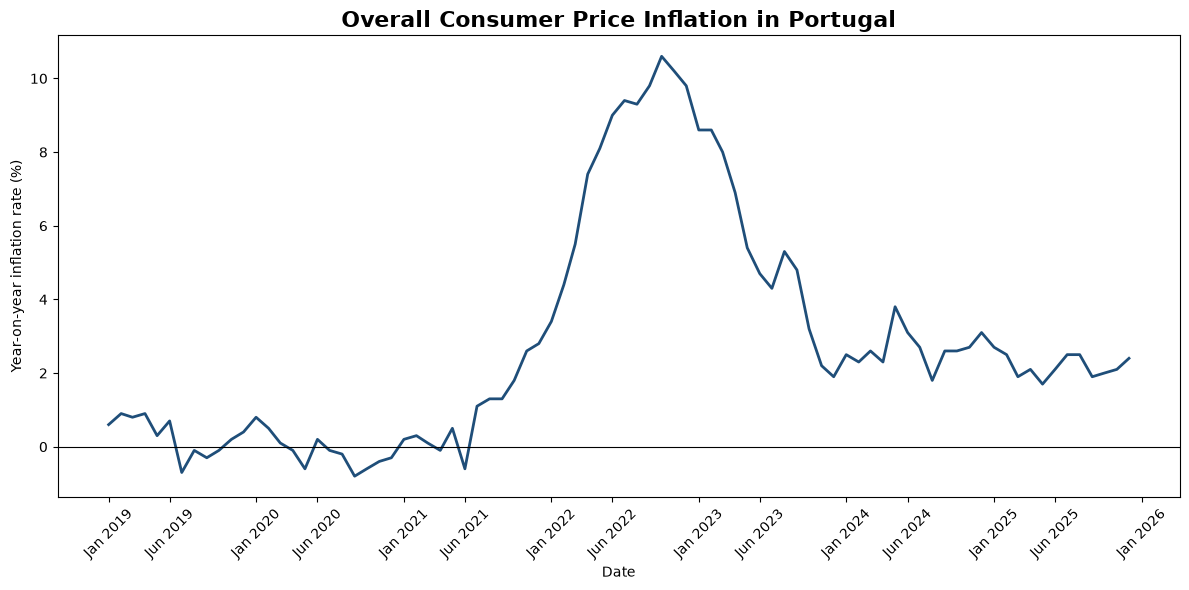

In [8]:
portugal_headline = hicp_merge[
    (hicp_merge["country"] == "Portugal") &
    (hicp_merge["category"] == "All-items HICP")
].copy()

portugal_headline["date_plot"] = portugal_headline["date"].astype(
    "datetime64[ns]"
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=portugal_headline,
    x="date_plot",
    y="homologous_inflation",
    color="#1f4e79",
    linewidth=2,
    ax=ax
)

ax.axhline(y=0, color="black", linewidth=0.8)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 6]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=45)

ax.set_title(
    "Overall Consumer Price Inflation in Portugal",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Year-on-year inflation rate (%)")

plt.tight_layout()
plt.show()

#### Plotting Portugal vs. Euro Area inflation:

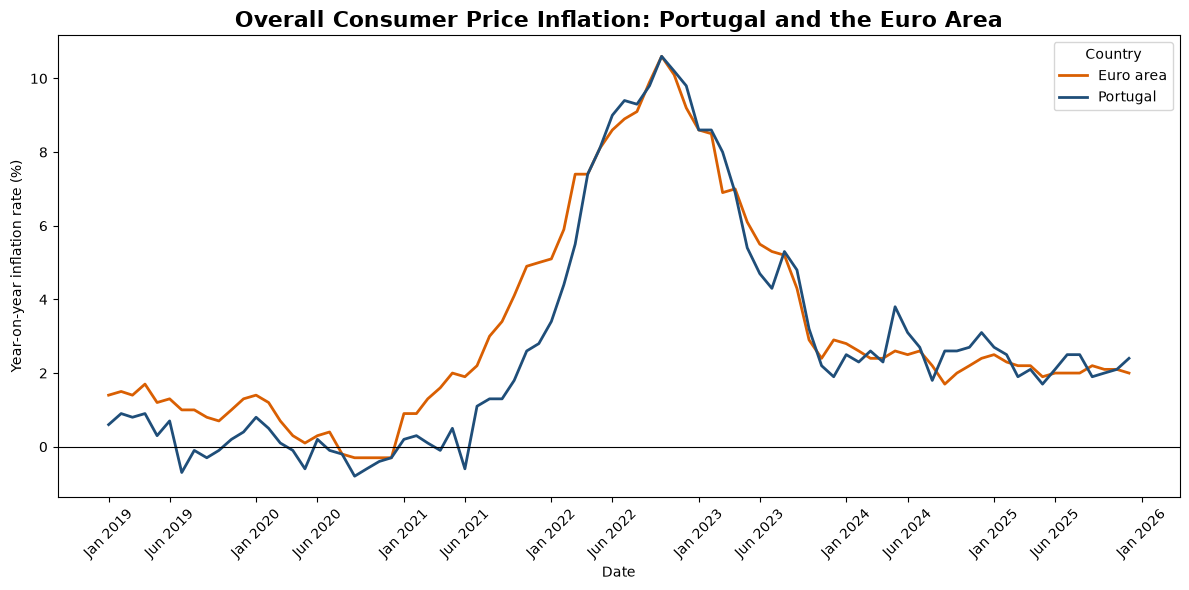

In [9]:
euro_area_name = hicp_merge.loc[
    hicp_merge["country"].str.startswith("Euro area"),
    "country"
].iloc[0]

portugal_euro = hicp_merge[
    (hicp_merge["category"] == "All-items HICP") &
    (hicp_merge["country"].isin(["Portugal", euro_area_name]))
].copy()

portugal_euro["date_plot"] = portugal_euro["date"].astype(
    "datetime64[ns]"
)

portugal_euro["country_label"] = portugal_euro["country"].replace(
    {euro_area_name: "Euro area"}
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=portugal_euro,
    x="date_plot",
    y="homologous_inflation",
    hue="country_label",
    palette={"Portugal": "#1f4e79", "Euro area": "#d95f02"},
    linewidth=2,
    ax=ax
)

ax.axhline(y=0, color="black", linewidth=0.8)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 6]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=45)

ax.set_title(
    "Overall Consumer Price Inflation: Portugal and the Euro Area",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Year-on-year inflation rate (%)")
ax.legend(title="Country")

plt.tight_layout()
plt.show()

#### Plotting inflation for all areas on dataset:

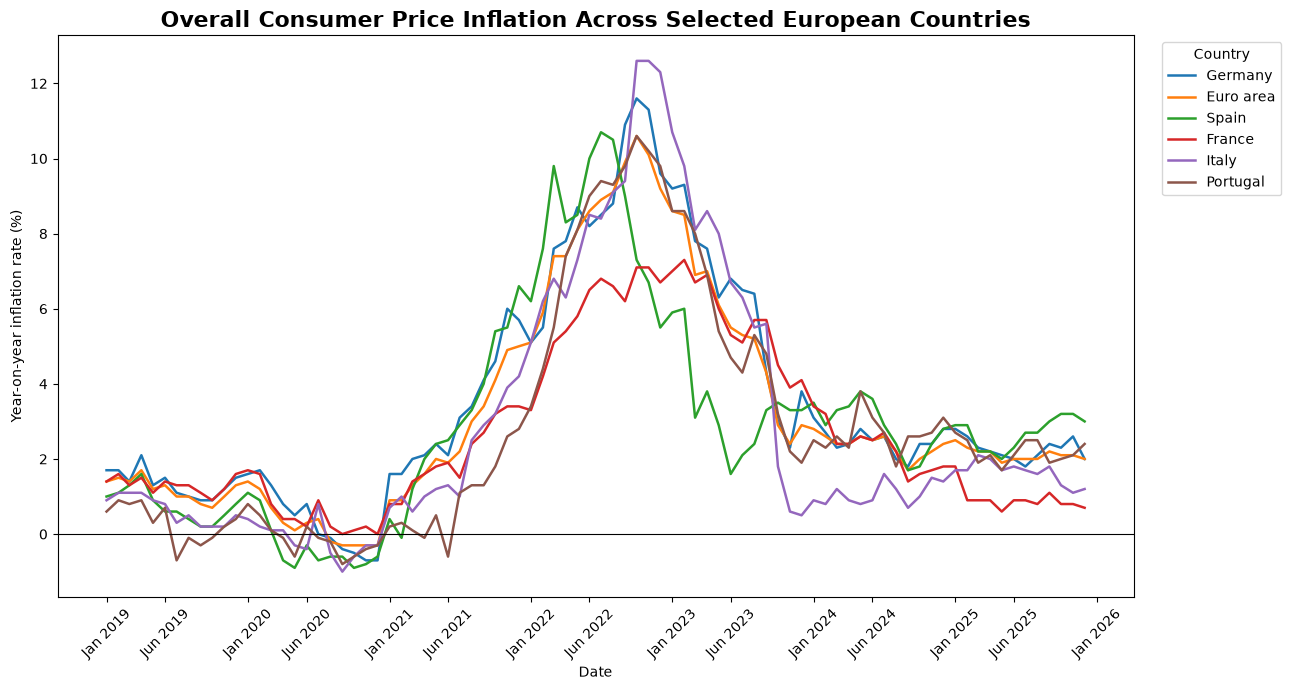

In [10]:
#for all countries:
all_headline = hicp_merge[
    hicp_merge["category"] == "All-items HICP"
].copy()

all_headline["date_plot"] = all_headline["date"].astype(
    "datetime64[ns]"
)

all_headline["country_label"] = all_headline["country"].replace(
    {euro_area_name: "Euro area"}
)

fig, ax = plt.subplots(figsize=(13, 7))

sns.lineplot(
    data=all_headline,
    x="date_plot",
    y="homologous_inflation",
    hue="country_label",
    palette="tab10",
    linewidth=1.8,
    ax=ax
)

ax.axhline(y=0, color="black", linewidth=0.8)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 6]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=45)

ax.set_title(
    "Overall Consumer Price Inflation Across Selected European Countries",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Year-on-year inflation rate (%)")

ax.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### Plotting an interactive Dashboard:

In [14]:
#interactive plot with plotly, of all regions on dataset:
import plotly.express as px

fig = px.line(
    all_headline,
    x="date_plot",
    y="homologous_inflation",
    color="country_label",
    title="Overall Consumer Price Inflation Across Selected European Countries",
    labels={
        "date_plot": "Date",
        "homologous_inflation": "Year-on-year inflation rate (%)",
        "country_label": "Country"
    }
)

fig.update_xaxes(
    dtick="M6",
    tickformat="%b %Y"
)

fig.update_layout(
    hovermode="x unified",
    legend_title_text="Country"
)

fig.update_layout(
    width=1200,
    height=700
)

fig.show()

### Observations: Overall consumer price inflation

This chart shows that headline consumer price inflation in Portugal and the euro area remained relatively low and broadly stable from January 2019 to December 2020.

Inflationary pressure began to increase during 2021 and continued to accelerate throughout 2022. In Portugal and all areas contemplated in the dataset, headline HICP inflation reached its highest point in October 2022. This period represents the most intense inflationary pressure observed in the dataset.

After the October 2022 peak, inflation declined until approximately November 2023. From that point onwards, the annual inflation rate remained relatively more stable than during the 2021–2022 inflationary shock, although it did not return to the low levels observed at the beginning of the period.

In January 2019, the annual inflation rate was approximately 1.4% in the euro area and 0.6% in Portugal. By December 2025, the corresponding rates were approximately 2.0% and 2.4%, respectively. This suggests that inflationary pressure at the end of the available period remained higher than at the beginning of the analysis.

**It is important to distinguish between a lower inflation rate and lower prices. A declining inflation rate means that prices are increasing more slowly than before; it does not necessarily mean that the overall price level has fallen. To measure cumulative price changes since 2019, an HICP price index dataset would be required.** 

The current dataset ends in December 2025 and cannot be used to assess inflation developments during 2026.

## Category Grouping and Analytical Framework

The HICP dataset contains a range of specific consumption categories, from individual food products such as olive oil and eggs to energy products, clothing, books and personal services.

To make the analysis more interpretable and allow for meaningful comparisons, selected categories are grouped into broader consumption themes. This creates an additional analytical layer while preserving the original HICP categories.

The groups used in the analysis are:

* **Food essentials** - staple food products such as bread, meat, fish, eggs, dairy, vegetables and potatoes.
* **Food & indulgence** - selected products such as olive oil, chocolate, coffee, wine and cigarettes.
* **Energy** - electricity, gas, petrol, diesel and the broader energy aggregate.
* **Housing** - housing, water, electricity, gas and other fuels.
* **Culture & information** - books.
* **Clothing** - clothing.
* **Discretionary consumption & services** - restaurants, cafés, hairdressing and personal grooming services.
* **Pet care** - veterinary and other services for pets.

Two aggregate categories, **All-items HICP** and **Food and non-alcoholic beverages**, are not assigned to a group. They are retained as reference categories and can be used as benchmarks against which individual products and groups can be compared.

This grouping is an analytical choice made for the purposes of this project. It does not replace the official HICP classification and should not be interpreted as an official Eurostat categorisation.

### Analytical Questions

The grouped data will be used to explore several aspects of consumer price inflation in Portugal:

1. **Food inflation:** When did inflation become most intense, and which food products were most affected?
2. **Everyday products:** How did the prices of selected familiar products, such as olive oil, eggs, chocolate and coffee, evolve over time?
3. **Energy:** How did different energy products behave during periods of rising and falling energy prices?
4. **Consumption categories:** Which selected categories experienced the largest cumulative price increases over the period?
5. **Headline inflation:** How did the evolution of individual products and consumption groups compare with overall HICP inflation?

The next step is to develop visualisations that answer these questions using different chart types, rather than relying exclusively on time-series line charts.

In [15]:
#checking the name of individual categories:
hicp_merge["category"].unique()

<StringArray>
[                                          'All-items HICP',
                         'Food and non-alcoholic beverages',
                                                    'Bread',
                                            'Beef and veal',
                                                     'Pork',
                                                  'Poultry',
                                    'Fresh or chilled fish',
                                    'Milk, cheese and eggs',
                                                     'Eggs',
                                                   'Butter',
                                                'Olive oil',
                                               'Vegetables',
                                                 'Potatoes',
                                                'Chocolate',
                                                   'Coffee',
                                         'Wine from grapes',
          

In [16]:
#making group categories:
group_map = {
    # Food essentials
    "Bread": "Food essentials",
    "Beef and veal": "Food essentials",
    "Pork": "Food essentials",
    "Poultry": "Food essentials",
    "Fresh or chilled fish": "Food essentials",
    "Milk, cheese and eggs": "Food essentials",
    "Eggs": "Food essentials",
    "Butter": "Food essentials",
    "Vegetables": "Food essentials",
    "Potatoes": "Food essentials",

    # Food & indulgence
    "Olive oil": "Food & indulgence",
    "Chocolate": "Food & indulgence",
    "Coffee": "Food & indulgence",
    "Wine from grapes": "Food & indulgence",
    "Cigarettes": "Food & indulgence",

    # Energy
    "Electricity": "Energy",
    "Gas": "Energy",
    "Diesel": "Energy",
    "Petrol": "Energy",
    "Energy": "Energy",

    # Housing
    "Housing, water, electricity, gas and other fuels": "Housing",

    # Culture & information
    "Books": "Culture & information",

    # Clothing
    "Clothing": "Clothing",

    # Discretionary consumption & services
    "Restaurants, cafés and the like": "Discretionary consumption & services",
    "Hairdressing salons and personal grooming establishments": "Discretionary consumption & services",

    # Pet care
    "Veterinary and other services for pets": "Pet care"
}

In [17]:
#creating the new column:
hicp_merge["category_group"] = hicp_merge["category"].map(group_map)

In [18]:
#checking for duplicates:
hicp_merge[["category", "category_group"]].drop_duplicates().sort_values(
    ["category_group", "category"]
)

,category,category_group
8568,Clothing,Clothing
12096,Books,Culture & information
13104,Hairdressing salons and personal grooming esta...,Discretionary consumption & services
12600,"Restaurants, cafés and the like",Discretionary consumption & services
10584,Diesel,Energy
9576,Electricity,Energy
13608,Energy,Energy
10080,Gas,Energy
11088,Petrol,Energy
6552,Chocolate,Food & indulgence


In [19]:
hicp_merge["category_group"].value_counts(dropna=False)

category_group
Food essentials                         5040
Food & indulgence                       2520
Energy                                  2520
NaN                                     1008
Discretionary consumption & services    1008
Clothing                                 504
Housing                                  504
Pet care                                 504
Culture & information                    504
Name: count, dtype: int64

## 1. **Food inflation:** 
When did inflation become most intense, and which food products were most affected?

#### Food Essentials

In [20]:
#filtering for Portugal and Food Essentials:
food_essentials = hicp_merge[
    (hicp_merge["country"] == "Portugal") &
    (hicp_merge["category_group"] == "Food essentials")
].copy()

food_essentials.head()

,category,country,date,homologous_inflation,year,item_weight,category_group
1428,Bread,Portugal,2019-01-01,1.4,2019,19.05,Food essentials
1429,Bread,Portugal,2019-02-01,1.3,2019,19.05,Food essentials
1430,Bread,Portugal,2019-03-01,1.2,2019,19.05,Food essentials
1431,Bread,Portugal,2019-04-01,0.8,2019,19.05,Food essentials
1432,Bread,Portugal,2019-05-01,1.0,2019,19.05,Food essentials


In [21]:
#calculating average annual inflation 
food_annual = (
    food_essentials
    .groupby(["category", "year"])
        ["homologous_inflation"]
        .mean()
        .reset_index()
)

food_annual.head()

,category,year,homologous_inflation
0,Beef and veal,2019,0.658333
1,Beef and veal,2020,-0.300000
2,Beef and veal,2021,2.908333
3,Beef and veal,2022,19.008333
4,Beef and veal,2023,7.441667


In [22]:
#creating a pivot table:
food_heatmap = food_annual.pivot(
    index="category",
    columns="year",
    values="homologous_inflation"
)

food_heatmap

year,2019,2020,2021,2022,2023,2024,2025
category,,,,,,,
Beef and veal,0.658333,-0.300000,2.908333,19.008333,7.441667,5.483333,18.166667
Bread,0.658333,0.775000,1.425000,13.958333,5.375000,5.066667,4.233333
Butter,3.291667,1.758333,0.541667,19.400000,8.833333,1.491667,6.291667
Eggs,-2.000000,-1.783333,1.833333,31.291667,16.141667,-1.333333,20.800000
Fresh or chilled fish,0.191667,2.333333,0.616667,11.616667,3.925000,4.475000,3.716667
"Milk, cheese and eggs",-1.558333,-0.508333,-0.083333,14.116667,13.933333,1.908333,2.158333
Pork,6.625000,12.325000,-1.608333,11.775000,10.091667,0.866667,0.950000
Potatoes,15.550000,-3.600000,-0.658333,16.883333,24.175000,4.475000,-3.500000
Poultry,-0.216667,1.025000,0.133333,26.166667,4.016667,1.125000,6.900000


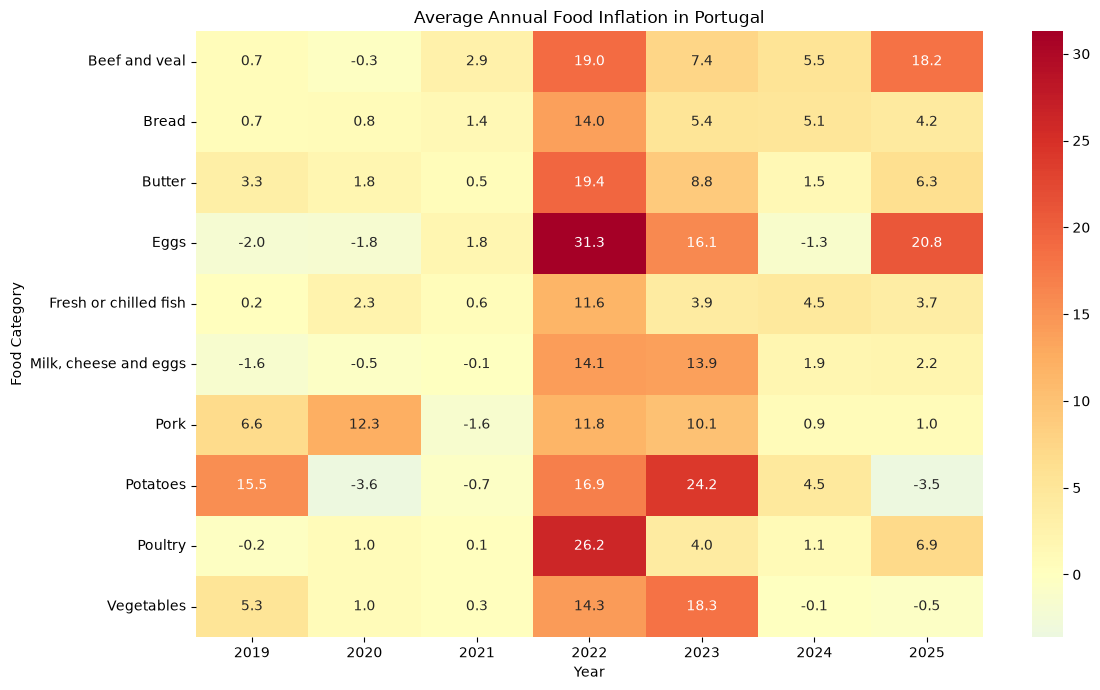

In [23]:
#creating a heatmap:
plt.figure(figsize=(12, 7))

sns.heatmap(
    food_heatmap,
    annot=True,
    fmt=".1f",
    center=0,
    cmap="RdYlBu_r"
)

plt.title("Average Annual Food Inflation in Portugal")
plt.xlabel("Year")
plt.ylabel("Food Category")
plt.tight_layout()

plt.show()

## 2. **Everyday products:** 
How did the prices of selected familiar products, such as olive oil, eggs, chocolate and coffee, evolve over time?

In [24]:
# Filtering for Portugal and Food & indulgence
food_indulgence = hicp_merge[
    (hicp_merge["country"] == "Portugal") &
    (hicp_merge["category_group"] == "Food & indulgence")
].copy()

food_indulgence.head()

,category,country,date,homologous_inflation,year,item_weight,category_group
5460,Olive oil,Portugal,2019-01-01,-3.4,2019,3.39,Food & indulgence
5461,Olive oil,Portugal,2019-02-01,-6.0,2019,3.39,Food & indulgence
5462,Olive oil,Portugal,2019-03-01,-4.2,2019,3.39,Food & indulgence
5463,Olive oil,Portugal,2019-04-01,-9.2,2019,3.39,Food & indulgence
5464,Olive oil,Portugal,2019-05-01,-6.5,2019,3.39,Food & indulgence


In [25]:
# Calculating average annual inflation
indulgence_annual = (
    food_indulgence
    .groupby(["category", "year"])["homologous_inflation"]
    .mean()
    .reset_index()
)

indulgence_annual.head()

,category,year,homologous_inflation
0,Chocolate,2019,-1.425000
1,Chocolate,2020,-3.108333
2,Chocolate,2021,2.991667
3,Chocolate,2022,2.825000
4,Chocolate,2023,10.966667


In [26]:
# Creating a pivot table
indulgence_heatmap = indulgence_annual.pivot(
    index="category",
    columns="year",
    values="homologous_inflation"
)

indulgence_heatmap

year,2019,2020,2021,2022,2023,2024,2025
category,,,,,,,
Chocolate,-1.425000,-3.108333,2.991667,2.825000,10.966667,9.900000,17.250000
Cigarettes,2.266667,1.466667,2.175000,1.758333,3.416667,5.283333,2.983333
Coffee,0.200000,0.033333,-0.091667,8.366667,8.375000,2.916667,9.391667
Olive oil,-7.183333,-8.375000,2.575000,14.541667,46.533333,35.641667,-24.016667
Wine from grapes,2.666667,-0.391667,-0.875000,3.450000,3.925000,-0.483333,-0.491667


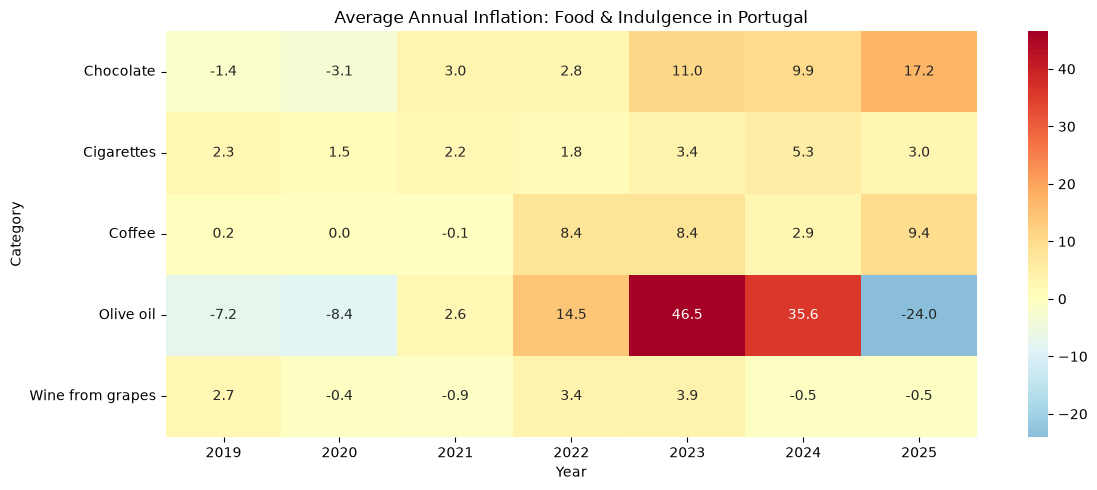

In [27]:
#creating the heatmap
plt.figure(figsize=(12, 5))

sns.heatmap(
    indulgence_heatmap,
    annot=True,
    fmt=".1f",
    center=0,
    cmap="RdYlBu_r"
)

plt.title("Average Annual Inflation: Food & Indulgence in Portugal")
plt.xlabel("Year")
plt.ylabel("Category")
plt.tight_layout()

plt.show()

## 3. **Energy:** 
How did different energy products behave during periods of rising and falling energy prices?


In [28]:
# Filtering for Portugal and Energy
energy = hicp_merge[
    (hicp_merge["country"] == "Portugal") &
    (hicp_merge["category_group"] == "Energy")
].copy()

energy.head()

,category,country,date,homologous_inflation,year,item_weight,category_group
9996,Electricity,Portugal,2019-01-01,-3.3,2019,28.1,Energy
9997,Electricity,Portugal,2019-02-01,-3.7,2019,28.1,Energy
9998,Electricity,Portugal,2019-03-01,-3.5,2019,28.1,Energy
9999,Electricity,Portugal,2019-04-01,-3.6,2019,28.1,Energy
10000,Electricity,Portugal,2019-05-01,-3.6,2019,28.1,Energy


In [29]:
# Calculating average annual inflation
energy_annual = (
    energy
    .groupby(["category", "year"])["homologous_inflation"]
    .mean()
    .reset_index()
)

energy_annual.head()

,category,year,homologous_inflation
0,Diesel,2019,1.625000
1,Diesel,2020,-8.308333
2,Diesel,2021,14.733333
3,Diesel,2022,25.908333
4,Diesel,2023,-11.008333


In [30]:
# Creating a pivot table
energy_heatmap = energy_annual.pivot(
    index="category",
    columns="year",
    values="homologous_inflation"
)

energy_heatmap

year,2019,2020,2021,2022,2023,2024,2025
category,,,,,,,
Diesel,1.625000,-8.308333,14.733333,25.908333,-11.008333,-0.250000,-0.050000
Electricity,-4.241667,-1.675000,0.758333,22.125000,-14.250000,14.241667,-0.691667
Energy,-1.683333,-5.158333,7.658333,23.741667,-8.483333,3.241667,-0.200000
Gas,-0.141667,-3.341667,1.633333,38.425000,14.016667,-9.991667,2.350000
Petrol,-2.666667,-6.275000,16.116667,14.291667,-6.541667,-0.050000,-0.341667


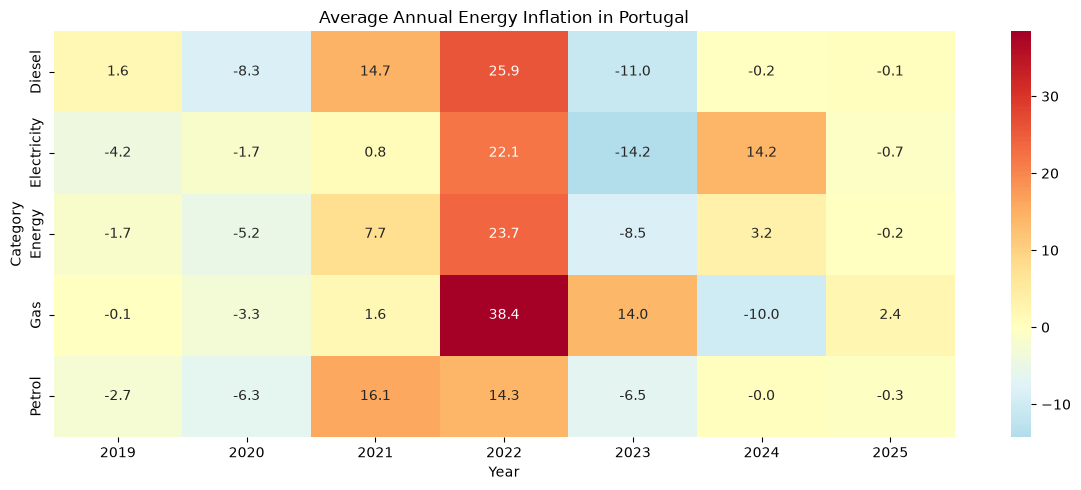

In [31]:
#creating the heatmap
plt.figure(figsize=(12, 5))

sns.heatmap(
    energy_heatmap,
    annot=True,
    fmt=".1f",
    center=0,
    cmap="RdYlBu_r"
)

plt.title("Average Annual Energy Inflation in Portugal")
plt.xlabel("Year")
plt.ylabel("Category")
plt.tight_layout()

plt.show()

## Heatmap Interpretation and Key Findings

The heatmaps show the average annual **homologous inflation rate** for selected categories in Portugal between 2019 and 2025. Each value represents the average of the monthly year-on-year inflation rates for that category during the corresponding year. Therefore, the figures indicate the intensity of price inflation relative to the same months of the previous year, rather than the cumulative change in prices over the year.

### Food essentials

The data show a clear increase in inflationary pressure across most food essentials in 2022. While most categories remained close to zero in 2019–2021, several experienced substantial increases in 2022. Eggs recorded the highest average annual homologous inflation rate in this group at **31.3%**, followed by poultry (**26.2%**), butter (**19.4%**) and beef and veal (**19.0%**).

Inflation remained elevated for several categories in 2023, although the pattern became more differentiated. Potatoes recorded particularly high average inflation (**24.2%**), while vegetables (**18.3%**) and eggs (**16.1%**) also remained strongly affected.

By 2024, average inflation had decreased considerably for most food essentials. However, 2025 shows that inflation did not evolve uniformly across categories. Eggs (**20.8%**) and beef and veal (**18.2%**) experienced renewed high average inflation, while potatoes (**-3.5%**) and vegetables (**-0.6%**) recorded negative average homologous inflation.

### Food & indulgence

The Food & indulgence group displays more differentiated trajectories.

Olive oil stands out particularly strongly. Its average homologous inflation increased from **14.5% in 2022** to **46.5% in 2023** and remained very high at **35.6% in 2024**. In 2025, however, the average rate became strongly negative (**-24.0%**), indicating that olive oil prices were, on average, substantially lower than in the corresponding months of 2024.

Chocolate also shows a gradual increase in inflationary pressure, reaching **17.3% in 2025**. Coffee followed a different trajectory, with inflation increasing from approximately zero in 2019–2021 to **8.4% in 2022 and 2023**, before reaching **9.4% in 2025**.

Wine from grapes remained comparatively stable throughout the period, with average annual inflation generally close to zero or in the low single digits.

### Energy

Energy categories show some of the strongest year-to-year fluctuations in the dataset.

After predominantly negative inflation rates in 2020, several energy categories experienced substantial inflation in 2021 and particularly in 2022. Gas recorded the highest average annual homologous inflation in the group in 2022 (**38.4%**), followed by diesel (**25.9%**), the overall Energy category (**23.7%**) and electricity (**22.1%**).

In 2023, the pattern changed substantially. Electricity, diesel, petrol and the overall Energy category recorded negative average homologous inflation, while gas remained positive at **14.0%**.

The divergence continued in 2024. Electricity returned to relatively high positive inflation (**14.2%**), while gas recorded negative average inflation (**-10.0%**). This highlights the different price trajectories of individual energy components.

### Overall interpretation

Across all three groups, **2022 emerges as a major period of increased inflationary pressure**, particularly for food essentials and energy. However, the subsequent years show that inflation did not follow a single uniform trajectory. Different products and categories experienced peaks, declines and reversals at different times.

The heatmaps therefore provide a useful overview of **when inflationary pressure was strongest and which categories experienced the largest changes in annual inflation rates**.

However, these figures should not be interpreted as measures of the contribution of each category to overall inflation. A category's inflation rate needs to be considered alongside its **weight in the consumer basket**. The `item_weight` variable will therefore be used in the next stage of the analysis to explore the relationship between price inflation and the relative importance of each category in household consumption.

Finally, because 2025 is the last complete year shown here, **2026 is excluded from the annual heatmap comparison**. The available 2026 data cover only part of the year and should not be treated as a full-year average.


# Item weights Analysis

In [32]:
#This creates a new dataframe containing only Portugal and the categories for which a 'category_group' was defined. Categories without a group, such as 'All-items HICP' and 'Food and non-alcoholic beverages', are excluded from this analysis.
#creating a dataframe for item weights in PT:
weights_pt = hicp_merge[
    (hicp_merge["country"] == "Portugal") &
    (hicp_merge["category_group"].notna())
].copy()

In [33]:
#inspecting the dataframe:
weights_pt[["category", "year", "item_weight"]].head(20)

,category,year,item_weight
1428,Bread,2019,19.05
1429,Bread,2019,19.05
1430,Bread,2019,19.05
1431,Bread,2019,19.05
1432,Bread,2019,19.05
1433,Bread,2019,19.05
1434,Bread,2019,19.05
1435,Bread,2019,19.05
1436,Bread,2019,19.05
1437,Bread,2019,19.05


In [34]:
#This provides descriptive statistics for `item_weight`, including the mean, standard deviation, quartiles, minimum and maximum values. It gives an initial overview of how the importance of the selected categories varies within the consumer basket.
weights_pt["item_weight"].describe()

count    2184.000000
mean       20.539121
std        26.061832
min         0.960000
25%         3.240000
50%        11.150000
75%        21.020000
max       117.430000
Name: item_weight, dtype: float64

In [35]:
#this provides descriptive statistics for `item_weight`, including the mean, standard deviation, quartiles, minimum and maximum values. It gives an initial overview of how the importance of the selected categories varies within the consumer basket.
#identifying category-years with more than one item weight:
weights_pt.groupby(
    ["category", "year"]
)["item_weight"].nunique().value_counts()

item_weight
1    182
Name: count, dtype: int64

In [36]:
weights_pt.groupby(
    ["category", "year"]
)["item_weight"].nunique().loc[lambda x: x > 1]

Series([], Name: item_weight, dtype: int64)

#### Create an annual item-weight table
The HICP dataset is monthly, so the same annual item weight appears across all months of a given year. Since the weight is constant within each category-year combination, we reduce the dataset to one observation per category and year.

In [37]:
weights_annual = (
    weights_pt[
        ["category", "year", "item_weight"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

#### Inspect the annual item-weight table

This displays the first observations of the annual item-weight dataset to verify that there is now one row per category and year.

In [38]:
weights_annual.head(20)

,category,year,item_weight
0,Bread,2019,19.05
1,Bread,2020,16.61
2,Bread,2021,19.55
3,Bread,2022,19.38
4,Bread,2023,17.44
5,Bread,2024,15.58
6,Bread,2025,17.70
7,Beef and veal,2019,7.79
8,Beef and veal,2020,7.00
9,Beef and veal,2021,8.14


### Check the size of the annual dataset

This checks the number of rows and columns in the annual item-weight table. We expect 182 rows, corresponding to 26 categories across 7 complete years (2019–2025).

In [39]:
weights_annual.shape

(182, 3)

### Identify the categories with the largest item weights

This ranks the selected categories by their item weight in 2025. The item weight represents the relative importance of each category within the HICP consumer basket.

In [40]:
weights_2025 = (
    weights_annual[weights_annual["year"] == 2025]
    .sort_values("item_weight", ascending=False)
)

weights_2025.head(15)

,category,year,item_weight
167,"Restaurants, cafés and the like",2025,100.12
118,"Housing, water, electricity, gas and other fuels",2025,91.40
181,Energy,2025,70.86
111,Clothing,2025,47.77
125,Electricity,2025,28.65
41,"Milk, cheese and eggs",2025,24.05
139,Diesel,2025,20.48
104,Cigarettes,2025,18.32
69,Vegetables,2025,18.03
6,Bread,2025,17.70


### Identify the categories with the smallest item weights

This ranks the categories with the smallest item weights in 2025. Comparing the largest and smallest weights helps illustrate how differently individual categories are represented in the consumer basket.

In [41]:
weights_2025.sort_values("item_weight").head(10)

,category,year,item_weight
55,Butter,2025,1.24
48,Eggs,2025,1.47
153,Veterinary and other services for pets,2025,1.72
160,Books,2025,2.90
76,Potatoes,2025,3.08
90,Coffee,2025,3.15
83,Chocolate,2025,4.12
62,Olive oil,2025,6.76
132,Gas,2025,7.35
20,Pork,2025,7.84


### Interpreting HICP item weights

HICP item weights are expressed in parts per thousand, with the overall consumer basket represented by 1,000. For example, a weight of 100 corresponds to approximately 10% of the consumer basket.

The selected categories do not form a mutually exclusive set. Some are aggregate categories while others are components of those aggregates (for example, `Energy` and `Electricity`, or `Milk, cheese and eggs` and `Eggs`). Therefore, their weights should not be summed. Instead, the weights are used to compare the relative importance of individual categories within the consumer basket.

### Largest HICP item weights in Portugal, 2025

This bar chart shows the 15 selected categories with the largest HICP item weights in 2025. The weights indicate the relative importance of each category in the consumer basket.

Because the selected categories include both aggregate categories and their components, the weights should be interpreted individually rather than added together.

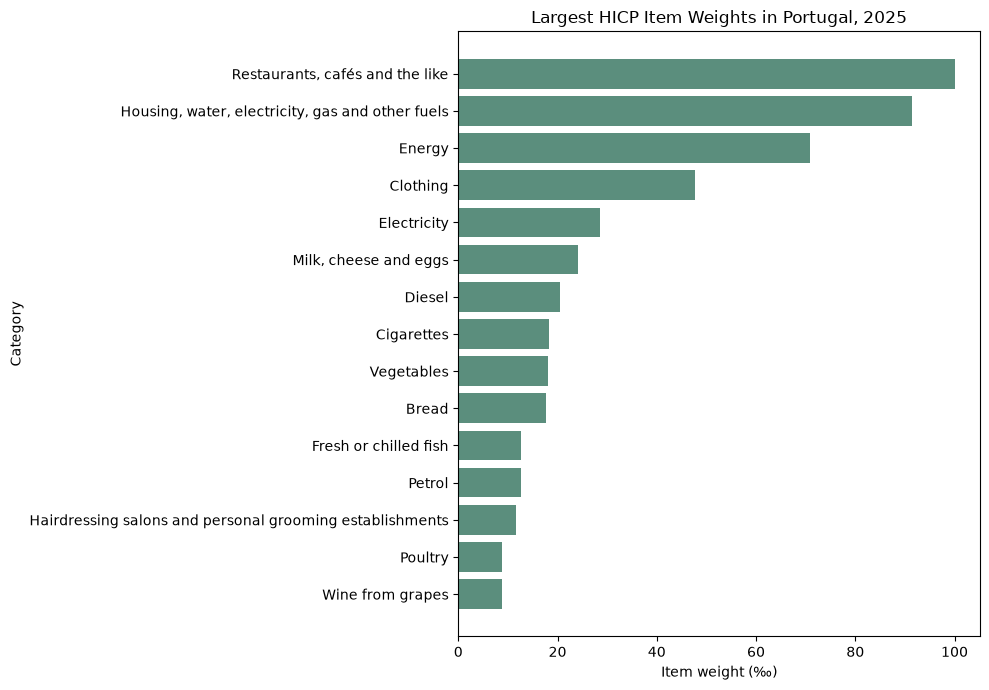

In [42]:
top_weights_2025 = weights_2025.head(15).sort_values("item_weight")

plt.figure(figsize=(10, 7))

plt.barh(
    top_weights_2025["category"],
    top_weights_2025["item_weight"],
    color="#5B8E7D"
)

plt.title("Largest HICP Item Weights in Portugal, 2025")
plt.xlabel("Item weight (‰)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

### Explore the evolution of HICP item weights

HICP item weights can change from year to year as household consumption patterns and expenditure structures change. This analysis compares the item weights of the selected categories between 2019 and 2025 to identify notable changes in their relative importance within the consumer basket.

In [43]:
weights_change = (
    weights_annual
    .pivot(
        index="category",
        columns="year",
        values="item_weight"
    )
)

weights_change

year,2019,2020,2021,2022,2023,2024,2025
category,,,,,,,
Beef and veal,7.79,7.00,8.14,8.62,8.26,7.41,7.96
Books,2.66,1.61,1.94,2.24,2.64,2.26,2.90
Bread,19.05,16.61,19.55,19.38,17.44,15.58,17.70
Butter,1.11,1.02,1.12,1.03,1.07,0.96,1.24
Chocolate,2.66,2.88,3.43,3.48,2.93,3.06,4.12
Cigarettes,18.66,17.87,21.02,18.62,17.28,16.80,18.32
Clothing,55.55,54.97,41.84,43.30,46.74,50.37,47.77
Coffee,2.95,2.70,3.32,3.32,3.06,3.22,3.15
Diesel,20.48,23.96,21.44,24.52,21.15,17.10,20.48


### Calculate average annual inflation by category

The HICP inflation data is recorded monthly, while item weights are available at the annual level. To compare the two measures consistently, we calculate the mean of the monthly year-on-year inflation rates for each category and year.

This produces one annual inflation value per category, matching the annual item-weight structure.

In [44]:
annual_inflation = (
    hicp_merge[
        (hicp_merge["country"] == "Portugal") &
        (hicp_merge["category_group"].notna())
    ]
    .groupby(["category", "year"])["homologous_inflation"]
    .mean()
    .reset_index()
)

annual_inflation.head()

,category,year,homologous_inflation
0,Beef and veal,2019,0.658333
1,Beef and veal,2020,-0.300000
2,Beef and veal,2021,2.908333
3,Beef and veal,2022,19.008333
4,Beef and veal,2023,7.441667


### Combine annual inflation with HICP item weights

The annual inflation measure and the annual item weight are now combined into a single dataset. This allows us to examine both price changes and the relative importance of each category in the consumer basket.

In [45]:
weights_inflation = annual_inflation.merge(
    weights_annual,
    on=["category", "year"],
    how="inner",
    validate="1:1"
)

weights_inflation.head()

,category,year,homologous_inflation,item_weight
0,Beef and veal,2019,0.658333,7.79
1,Beef and veal,2020,-0.300000,7.00
2,Beef and veal,2021,2.908333,8.14
3,Beef and veal,2022,19.008333,8.62
4,Beef and veal,2023,7.441667,8.26


### Verify the combined dataset

This checks the structure of the merged dataset and confirms that each category-year combination appears exactly once after combining annual inflation and item weights.

In [46]:
weights_inflation.shape

(182, 4)

### Select 2025 for the weight-inflation comparison

2025 is the latest complete year in our dataset. We use it as a reference year to compare the relative importance of each category in the HICP basket with its average annual inflation.

In [47]:
weights_inflation_2025 = (
    weights_inflation[
        weights_inflation["year"] == 2025
    ]
    .copy()
)

weights_inflation_2025

,category,year,homologous_inflation,item_weight
6,Beef and veal,2025,18.166667,7.96
13,Books,2025,1.991667,2.90
20,Bread,2025,4.233333,17.70
27,Butter,2025,6.291667,1.24
34,Chocolate,2025,17.250000,4.12
41,Cigarettes,2025,2.983333,18.32
48,Clothing,2025,-0.583333,47.77
55,Coffee,2025,9.391667,3.15
62,Diesel,2025,-0.050000,20.48
69,Eggs,2025,20.800000,1.47


### Compare item weight and annual inflation

This scatter plot compares the relative importance of each category in the HICP basket with its average annual inflation in 2025.

Each point represents one category. Categories further to the right have a larger weight in the consumer basket, while categories higher on the chart experienced higher average annual inflation.

The plot is exploratory: a category's position does not by itself indicate its contribution to overall inflation.

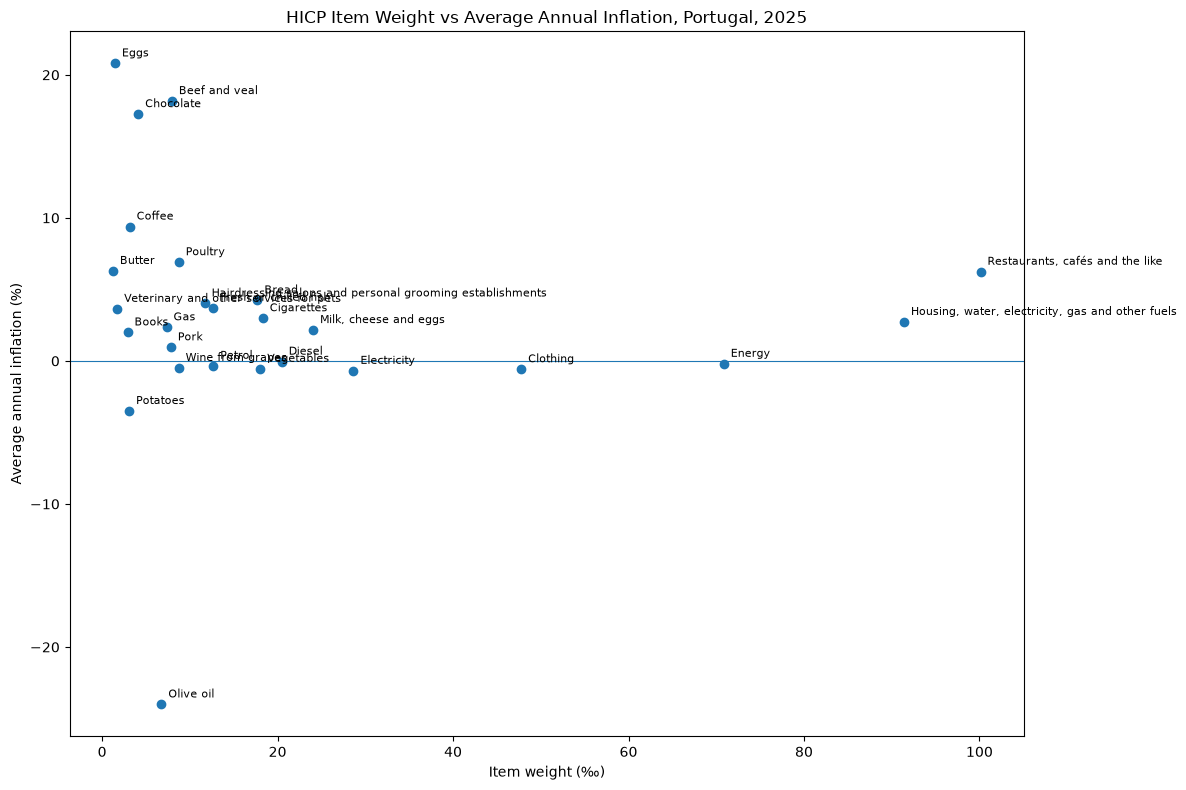

In [49]:
plt.figure(figsize=(12, 8))

plt.scatter(
    weights_inflation_2025["item_weight"],
    weights_inflation_2025["homologous_inflation"]
)

for _, row in weights_inflation_2025.iterrows():
    plt.annotate(
        row["category"],
        (row["item_weight"], row["homologous_inflation"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Item weight (‰)")
plt.ylabel("Average annual inflation (%)")
plt.title("HICP Item Weight vs Average Annual Inflation, Portugal, 2025")

plt.axhline(0, linewidth=0.8)
plt.tight_layout()
plt.show()

### Interpreting the weight-inflation scatter plot

The scatter plot compares the relative importance of selected categories in the Portuguese HICP consumer basket with their average annual inflation in 2025.

Each point represents one category. The horizontal position indicates its item weight in the consumer basket, while the vertical position indicates its average annual year-on-year inflation rate.

Most categories are concentrated in the lower-left area of the chart, reflecting relatively low item weights and moderate inflation rates. A smaller number of categories stand further to the right or higher on the chart, indicating greater basket weights or higher inflation.

This visualisation is exploratory. A category with high inflation does not necessarily have a large effect on overall inflation if its weight in the consumer basket is small. Conversely, a category with a large weight may have a more limited effect if its inflation rate is low. Therefore, item weight and inflation should be considered together when assessing the relative importance of price changes.


## Olive Oil inflation trends:

In [50]:
olive_oil = hicp_merge[
    (hicp_merge["country"] == "Portugal") &
    (hicp_merge["category"] == "Olive oil")
].copy()

olive_oil.head()

,category,country,date,homologous_inflation,year,item_weight,category_group
5460,Olive oil,Portugal,2019-01-01,-3.4,2019,3.39,Food & indulgence
5461,Olive oil,Portugal,2019-02-01,-6.0,2019,3.39,Food & indulgence
5462,Olive oil,Portugal,2019-03-01,-4.2,2019,3.39,Food & indulgence
5463,Olive oil,Portugal,2019-04-01,-9.2,2019,3.39,Food & indulgence
5464,Olive oil,Portugal,2019-05-01,-6.5,2019,3.39,Food & indulgence


In [51]:
olive_oil[["date", "homologous_inflation"]].head(20)

,date,homologous_inflation
5460,2019-01-01,-3.4
5461,2019-02-01,-6.0
5462,2019-03-01,-4.2
5463,2019-04-01,-9.2
5464,2019-05-01,-6.5
5465,2019-06-01,-7.8
5466,2019-07-01,-9.5
5467,2019-08-01,-5.7
5468,2019-09-01,-11.9
5469,2019-10-01,-12.0


In [52]:
olive_oil[["date", "homologous_inflation"]].tail(20)

,date,homologous_inflation
5524,2024-05-01,50.7
5525,2024-06-01,48.6
5526,2024-07-01,48.2
5527,2024-08-01,32.1
5528,2024-09-01,23.7
5529,2024-10-01,11.1
5530,2024-11-01,1.0
5531,2024-12-01,-2.3
5532,2025-01-01,-11.1
5533,2025-02-01,-17.2


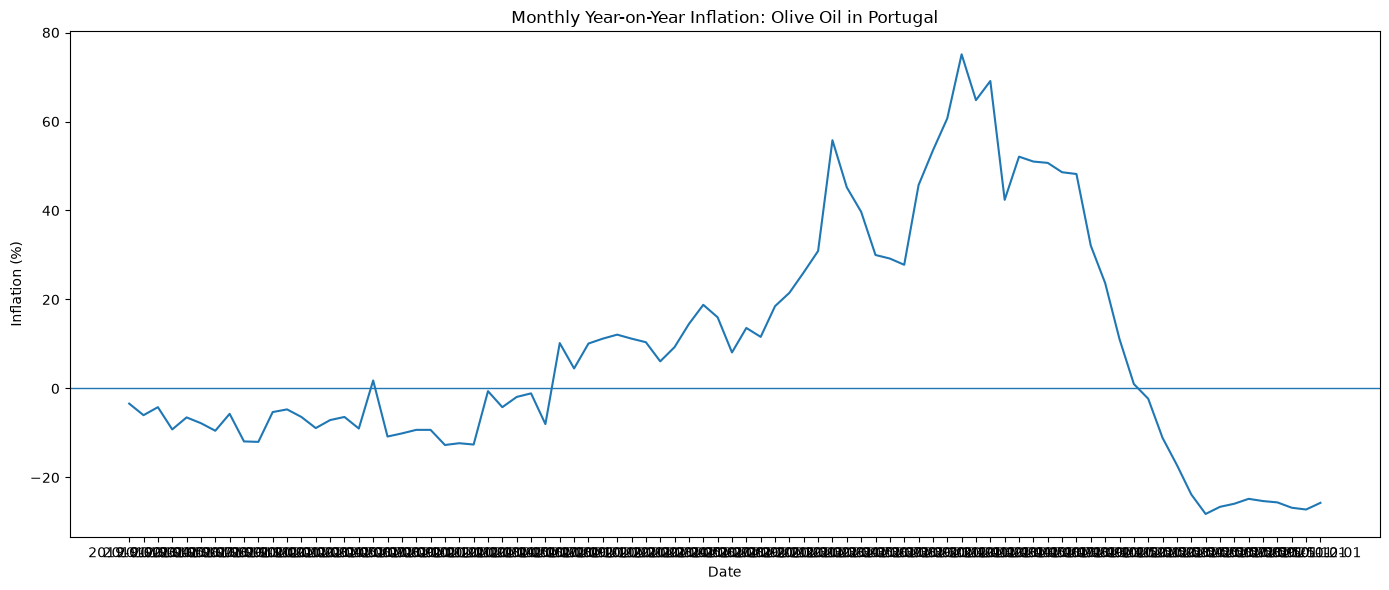

In [53]:
plt.figure(figsize=(14, 6))

plt.plot(
    olive_oil["date"],
    olive_oil["homologous_inflation"]
)

plt.axhline(0, linewidth=1)

plt.title("Monthly Year-on-Year Inflation: Olive Oil in Portugal")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")

plt.tight_layout()
plt.show()